In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

In [ ]:
panne = pd.read_csv(r"C:\Users\Dell\Desktop\Prédiction_Panne_KOMAX\notebooks\data processing\train_clean_enc.csv")
panne = panne.drop(columns=[col for col in ['Id', 'SalePrice'] if col in panne.columns])
one_hot_cols = [col for col in panne.columns if panne[col].dropna().isin([True, False]).all()]
panne = panne.drop(columns=one_hot_cols)
print(panne.head())

   Intervention Time (min)  Hour  Down Time (min)  Reaction Time (min)  \
0                     8.87  19.0            10.02                 0.17   
1                     4.04  17.0             6.57                 0.18   
2                    32.22  20.0            37.50                 1.13   
3                     3.56  22.0            10.97                 0.05   
4                     4.04   3.0            12.00                 0.07   

   Waiting Time (min)  Delay Time (min)  Machine_label  Type Of Failure_label  \
0                1.17              1.17             29                      8   
1                2.53              2.53              6                      8   
2                5.28              5.28             34                      9   
3                7.42              7.42              5                      8   
4                7.97              7.97             55                      5   

   Serial Device_label  Shift_label  Comment_Clean_label  \
0       

In [ ]:
print(panne.shape)

(20547, 14)


In [ ]:
scaler = StandardScaler()
panne_scaled = scaler.fit_transform(panne)

In [ ]:
pca = PCA()
pca.fit(panne_scaled)
pca_data = pca.transform(panne_scaled)

In [ ]:
per_var = np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = ['PC' + str(x) for x in range (1, len(per_var)+1)]

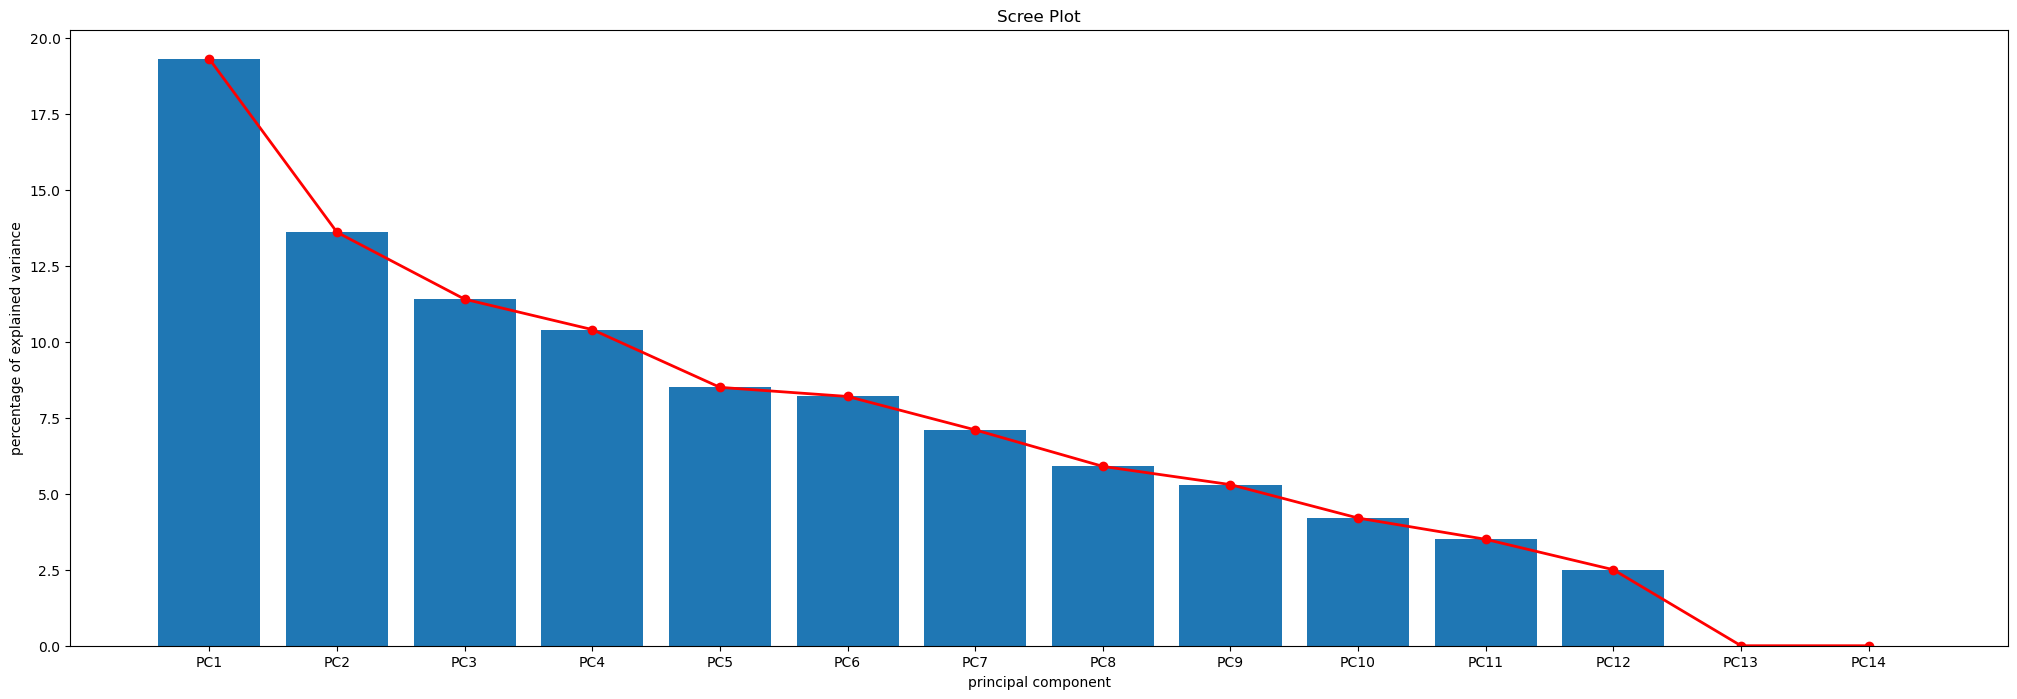

In [ ]:
plt.figure(figsize=(25, 8))
plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.plot(range(1, len(per_var)+1), per_var, color='red', marker='o', linestyle='-', linewidth=2, label='Explained Variance Curve')

plt.ylabel('percentage of explained variance')
plt.xlabel('principal component')
plt.title('Scree Plot')
plt.show()

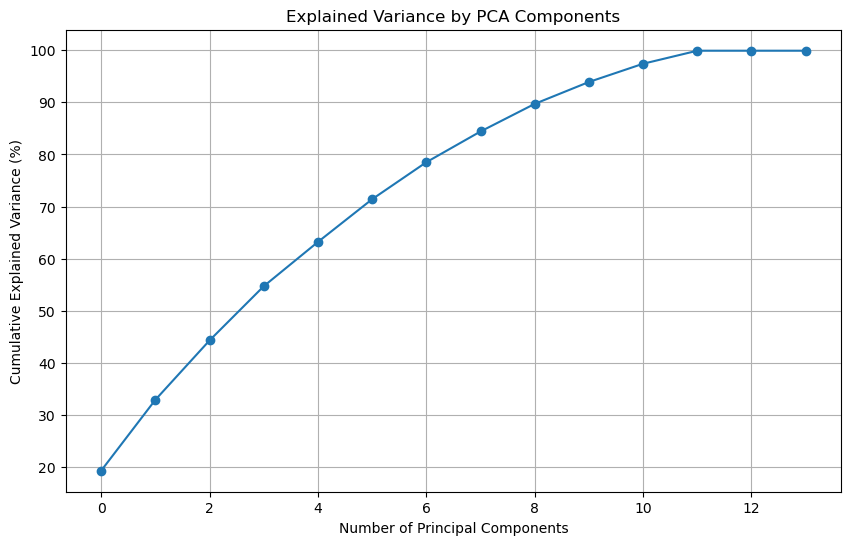

In [ ]:
cumulative = np.cumsum(per_var)
plt.figure(figsize=(10, 6))
plt.plot(cumulative[:50], marker='o')  # adjust number if needed
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

In [ ]:
cumulative_var = np.cumsum(per_var)
num_needed = np.argmax(cumulative_var >= 95) + 1
print(f"Number of components needed to explain 95% variance: {num_needed}")


Number of components needed to explain 95% variance: 11


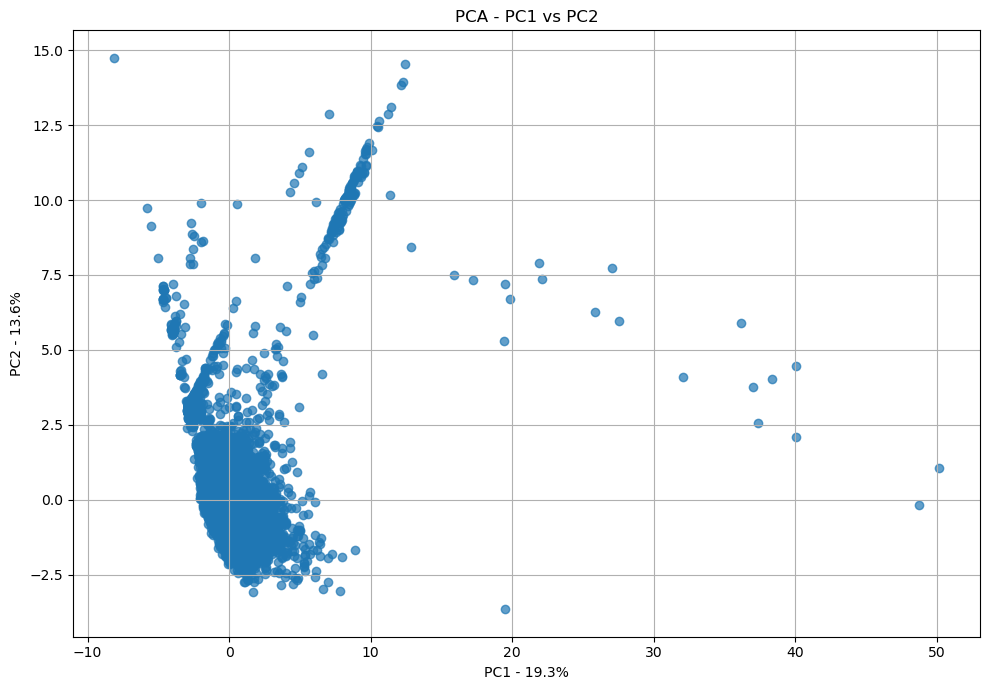

In [ ]:
# Create a DataFrame of the PCA-transformed data
pca_df = pd.DataFrame(pca_data, columns=labels)

# Scatter plot of PC1 vs PC2
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.title('PCA - PC1 vs PC2')
plt.xlabel(f'PC1 - {per_var[0]}%')
plt.ylabel(f'PC2 - {per_var[1]}%')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Get feature names (column names before PCA)
features = panne.columns

# Get loading scores (weights) for PC1
loading_scores = pd.Series(pca.components_[0], index=features)

# Sort by absolute value
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

# top 10 contributing features to PC1
top_features = sorted_loading_scores.index

# Print actual loading scores (with sign)
print("Top 10 features contributing to PC1:")
print(loading_scores[top_features])


Top 10 features contributing to PC1:
Waiting Time (min)             0.479562
Delay Time (min)               0.479562
Down Time (min)                0.454303
Intervention Time (min)        0.373378
Defect Code_label              0.193436
Microstop Description_label    0.183684
Type Of Failure_label          0.180925
Reaction Time (min)           -0.175009
Delay Time (min)_label         0.171673
Shift_label                    0.117913
Hour                          -0.117678
Serial Device_label           -0.034904
Comment_Clean_label           -0.025299
Machine_label                 -0.025252
dtype: float64


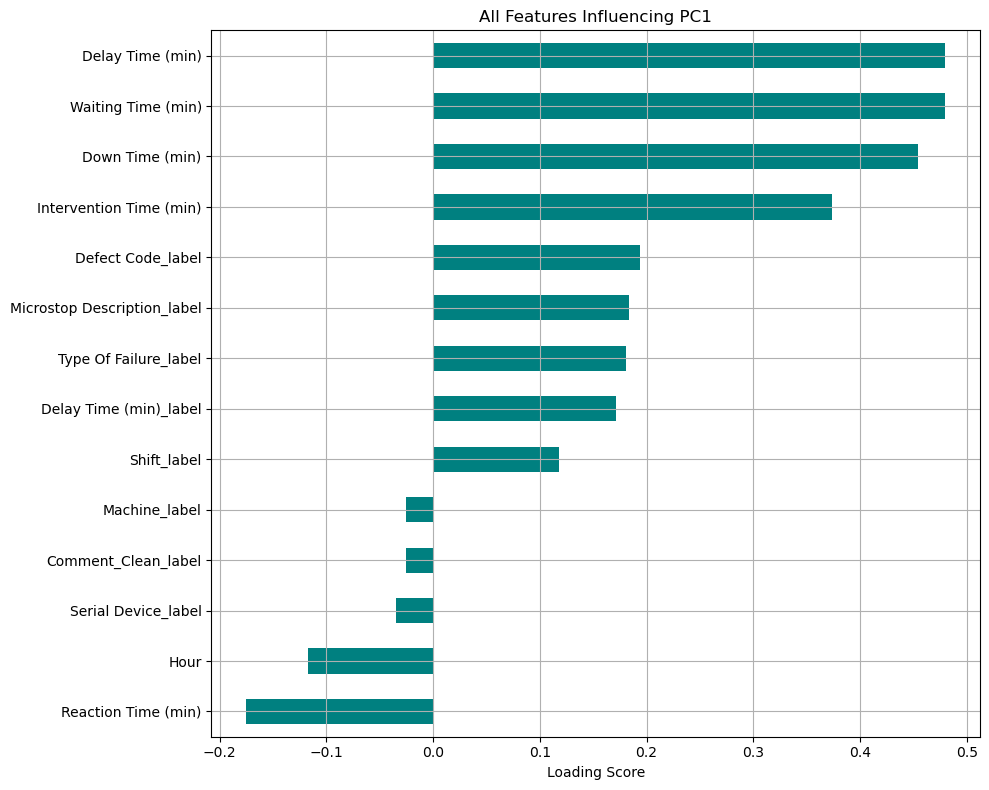

In [ ]:
# top 10 features contributing to PC1
plt.figure(figsize=(10, 8))
loading_scores[top_features].sort_values().plot(kind='barh', color='teal')
plt.title('All Features Influencing PC1')
plt.xlabel('Loading Score')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Get feature names (column names before PCA)
features = panne.columns

# Get loading scores (weights) for PC1
loading_scores_pc2 = pd.Series(pca.components_[1], index=features)

# Sort by absolute value
sorted_loading_scores_pc2 = loading_scores_pc2.abs().sort_values(ascending=False)

# top 10 contributing features to PC1
top_10_features_pc2 = sorted_loading_scores_pc2.head(10).index

# Print actual loading scores (with sign)
print("Top 10 features contributing to PC2:")
print(loading_scores[top_10_features_pc2])

Top 10 features contributing to PC2:
Intervention Time (min)    0.373378
Down Time (min)            0.454303
Reaction Time (min)       -0.175009
Delay Time (min)_label     0.171673
Comment_Clean_label       -0.025299
Shift_label                0.117913
Serial Device_label       -0.034904
Hour                      -0.117678
Type Of Failure_label      0.180925
Delay Time (min)           0.479562
dtype: float64


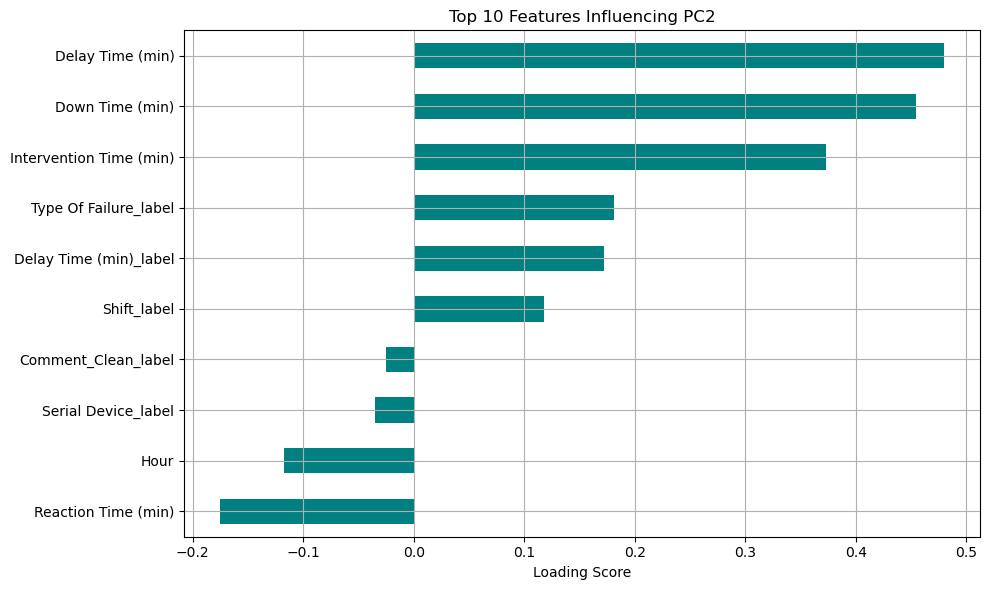

In [ ]:
# top 10 features contributing to PC2
plt.figure(figsize=(10, 6))
loading_scores[top_10_features_pc2].sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Features Influencing PC2')
plt.xlabel('Loading Score')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Get feature names (column names before PCA)
features = panne.columns

# Get loading scores (weights) for PC1
loading_scores_pc3 = pd.Series(pca.components_[2], index=features)

# Sort by absolute value
sorted_loading_scores_pc3 = loading_scores_pc3.abs().sort_values(ascending=False)

# top 10 contributing features to PC1
top_10_features_pc3 = sorted_loading_scores_pc3.head(10).index

# Print actual loading scores (with sign)
print("Top 10 features contributing to PC3:")
print(loading_scores[top_10_features_pc3])

Top 10 features contributing to PC3:
Hour                      -0.117678
Delay Time (min)           0.479562
Waiting Time (min)         0.479562
Shift_label                0.117913
Type Of Failure_label      0.180925
Defect Code_label          0.193436
Intervention Time (min)    0.373378
Reaction Time (min)       -0.175009
Down Time (min)            0.454303
Delay Time (min)_label     0.171673
dtype: float64


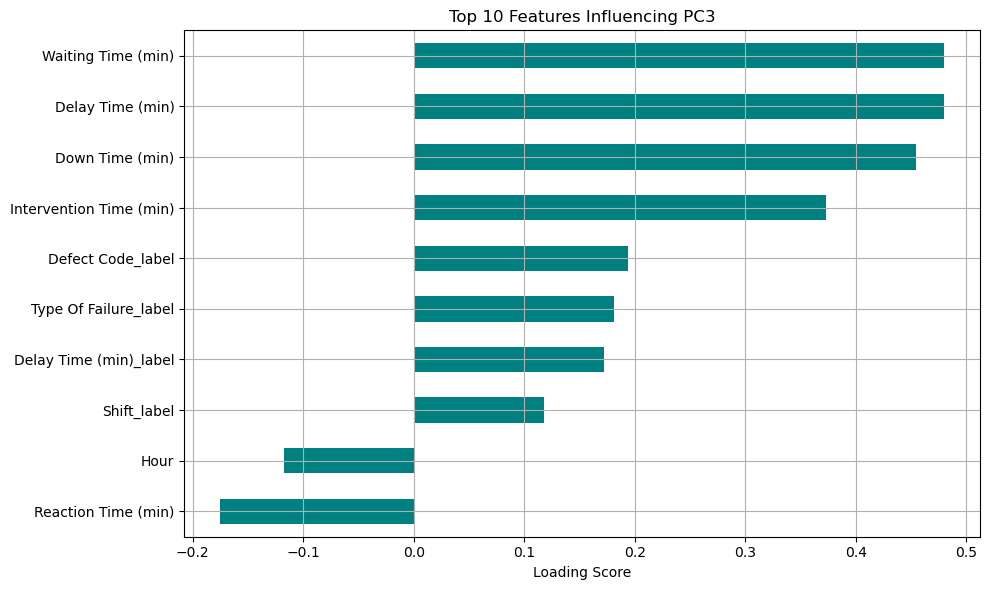

In [ ]:
# top 10 features contributing to PC3
plt.figure(figsize=(10, 6))
loading_scores[top_10_features_pc3].sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Features Influencing PC3')
plt.xlabel('Loading Score')
plt.grid(True)
plt.tight_layout()
plt.show()